<a href="https://colab.research.google.com/github/jfavian2011/Data-Science-Cohort-20/blob/main/Project__6_Images_To_Do_List.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Images – To Do List



Prior to starting this problem, be sure to enable the GPU runtime processing in your Jupyter notebook.



## Problem Definition


Train a binary image classifier using transfer learning on the Cats vs. Dogs dataset to accurately identify the species with at least 75% predictive confidence.


* Write a concise problem definition for the project. Put it in a text field at the top of your Jupyter notebook.

* Load necessary packages.



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests
from io import BytesIO

import tensorflow as tf
from tensorflow.keras import Sequential, Input
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPooling2D
from tensorflow.keras.preprocessing import image
from sklearn.model_selection import train_test_split
from tensorflow.keras.layers import Dropout

## Data Collection



* Load pickled data from X.pickle and y.pickle from the AWS S3 bucket.



In [2]:
images_url = "https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/X.pickle"
images_url

'https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/X.pickle'

In [3]:
#prepare array data
image_array = pd.read_pickle( images_url )
type(image_array)

numpy.ndarray

In [4]:
image_array.shape

(24946, 100, 100, 1)

In [5]:
target_url = "https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/y.pickle"
target_url

'https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/y.pickle'

In [6]:
target = pd.read_pickle( target_url )
type(target)

list

In [7]:
#fetching the source pixel arrays and target matrices from the remote AWS S3 bucket.

print("Loading data from remote AWS S3 Storage...")
images_url = "https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/X.pickle"
target_url = "https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/y.pickle"

#load serialized pickle objects using pandas
image_array = pd.read_pickle(images_url)
target_list = pd.read_pickle(target_url)
target_array = np.array(target_list)

print(f"-> Features Loaded: Shape {image_array.shape} ({type(image_array)})")
print(f"-> Targets Loaded: Length {len(target_array)} ({type(target_array)})")

Loading data from remote AWS S3 Storage...
-> Features Loaded: Shape (24946, 100, 100, 1) (<class 'numpy.ndarray'>)
-> Targets Loaded: Length 24946 (<class 'numpy.ndarray'>)


## Data Cleaning



* Scale the values in X so that they fall between 0 and 1 by dividing by 255.



In [8]:
# normalizing data inputs. grayscale image pixels map from 0 to 255.
# scale these values to a float range between 0.0 and 1.0 to ensure stable descent.

print("Original Data Pixel Range:", image_array.min(), "to", image_array.max())

# scale values to fall between 0 and 1
X_scaled = (image_array / 255.0).astype(np.float32)
y_labels = target_array.copy()

print("Cleaned Data Pixel Range: ", X_scaled.min(), "to", X_scaled.max())
print("Cleaned Data Type:        ", X_scaled.dtype)

Original Data Pixel Range: 0 to 255
Cleaned Data Pixel Range:  0.0 to 1.0
Cleaned Data Type:         float32


## Exploratory Data Analysis



* Look at the shape of X and y. Ensure that X is 4 dimensional.

* Plot a few ( >5 ) of the images in X using `plt.imshow()`.

* Look at the response values in y for those images.

* Hint: you may want to start with a random subset to get familiar with the process of building a NN.  Then go through the process again with the full set.



Dataset Balance Matrix:
  Dog (0): 12470 samples (49.99%)
  Cat (1): 12476 samples (50.01%)


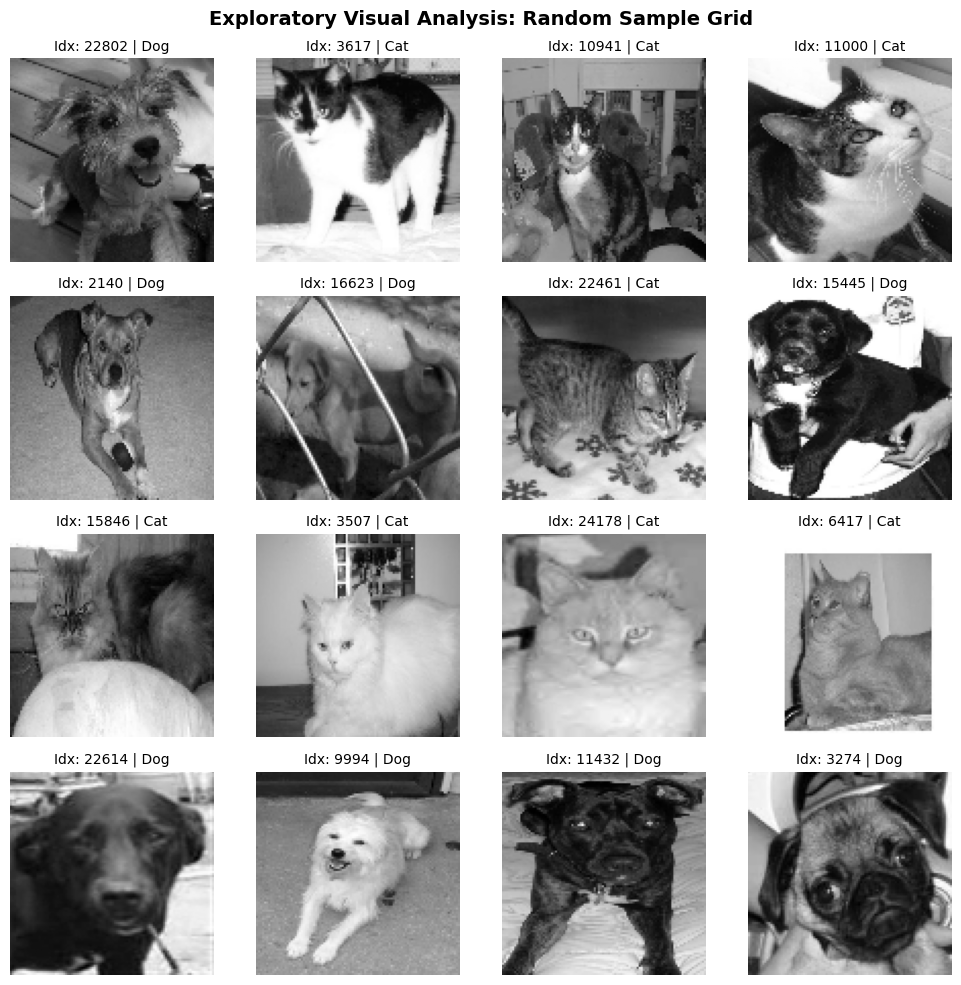

In [9]:
# class balancing metrics and plotting a random batch of the parsed image files.

unique_classes, class_counts = np.unique(y_labels, return_counts=True)
print("Dataset Balance Matrix:")
for cls, count in zip(unique_classes, class_counts):
    label_name = "Cat (1)" if cls == 1 else "Dog (0)"
    print(f"  {label_name}: {count} samples ({count/len(y_labels)*100:.2f}%)")

# visual 4x4 grid of sample records of dataset
rows, cols = 4, 4
np.random.seed(42)
random_indices = np.random.choice(len(X_scaled), size=rows*cols, replace=False)

fig, axes = plt.subplots(rows, cols, figsize=(10, 10))
for i, ax in enumerate(axes.flat):
    idx = random_indices[i]
    img = X_scaled[idx]
    label = "Cat" if y_labels[idx] == 1 else "Dog"

    ax.imshow(img.squeeze(), cmap='gray')
    ax.set_title(f"Idx: {idx} | {label}", fontsize=10)
    ax.axis('off')

plt.suptitle("Exploratory Visual Analysis: Random Sample Grid", fontsize=14, weight='bold')
plt.tight_layout()
plt.show()

## Data Processing



* Split X and y into training and testing sets.

*  Build a convolutional neural network with the following:
  * Sequential layers
  * At least two 2D convolutional layers using the 'relu' activation function and a (3,3) kernel size.
  * A MaxPooling2D layer after each 2D convolutional layer that has a pool size of (2,2).
  * A dense output layer using the 'sigmoid' activation function.
  Note: you can play around with the number of layers and nodes to try to get better performance.

* Compile your model. Use the 'adam' optimizer. Determine which loss function and metric is most appropriate for this problem.

* Fit your model using the training set.

* Evaluate your model using the testing set.

* Plot the distribution of probabilities for the testing set.

* Define a function that will read in a new image and convert it to a 4 dimensional array of pixels (ask the instructor for help with this). Hint: [numpy.reshape]( https://numpy.org/doc/stable/reference/generated/numpy.reshape.html )

* Use the function defined above to read in the dog.jpg image that is saved in the AWS S3 bucket.

* Use the neural network you created to predict whether the image is a dog or a cat.



Data Processing Verification:
  -> X_train shape: (19956, 100, 100, 1) | y_train shape: (19956,)
  -> X_test shape:  (4990, 100, 100, 1)  | y_test shape:  (4990,)


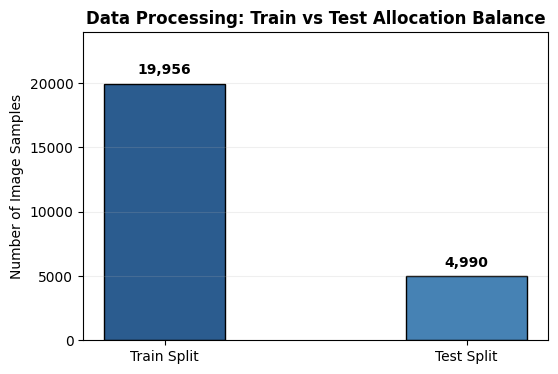

In [10]:
# stratifying and partitioning the complete dataset to guarantee a stable gradient descent.

# 1. ensure the target array is flat and matches the length of your images
y_labels = np.array(target_list).flatten()

# 2. perform a clean, stratified split on the entire dataset
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_labels, test_size=0.20, stratify=y_labels, random_state=42
)

print("Data Processing Verification:")
print(f"  -> X_train shape: {X_train.shape} | y_train shape: {y_train.shape}")
print(f"  -> X_test shape:  {X_test.shape}  | y_test shape:  {y_test.shape}")

# visualizing sample partition balance using a bar graph
partitions = ['Train Split', 'Test Split']
counts = [X_train.shape[0], X_test.shape[0]]

plt.figure(figsize=(6, 4))
bars = plt.bar(partitions, counts, color=['#2b5c8f', '#4682b4'], edgecolor='black', width=0.4)
plt.title('Data Processing: Train vs Test Allocation Balance', fontsize=12, weight='bold')
plt.ylabel('Number of Image Samples')
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 500, f'{yval:,}', ha='center', va='bottom', fontweight='bold')
plt.ylim(0, max(counts) + 4000)
plt.grid(axis='y', alpha=0.2)
plt.show()

In [11]:
# multi-layered CNN architecture engineered to map structural details for high-confidence classification.

model = Sequential([
    Input(shape=(100, 100, 1)),

    #  1: edges and base lines
    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),

    #  2: structural shapes
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),

    #  3: complex features (ears, eyes, textures)
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),

    # classification Head
    Flatten(),
    Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.4),   # Prevents from over-relying on specific pixel pathways
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')  # Outputs 0.0 for Dog, 1.0 for Cat
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 98, 98, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 49, 49, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 47, 47, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 21, 21, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,638,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,739,521 (6.64 MB)

 Trainable params: 1,739,521 (6.64 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
# executing backpropagation over our cleanly aligned dataset.

stable_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=4,
    restore_best_weights=True
)

print("Beginning model training on the full dataset split...")
history = model.fit(
    X_train, y_train,
    epochs=12,
    batch_size=64,
    validation_data=(X_test, y_test),
    callbacks=[stable_stop],
    verbose=1
)
print("\nTraining run successfully completed.")

Beginning model training on the full dataset split...
Epoch 1/12
312/312 ━━━━━━━━━━━━━━━━━━━━ 18s 37ms/step - accuracy: 0.6020 - loss: 0.6559 - val_accuracy: 0.6952 - val_loss: 0.5710
Epoch 2/12
312/312 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.7565 - loss: 0.5068 - val_accuracy: 0.7870 - val_loss: 0.4569
Epoch 3/12
312/312 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - accuracy: 0.8024 - loss: 0.4316 - val_accuracy: 0.7994 - val_loss: 0.4368
Epoch 4/12
312/312 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.8347 - loss: 0.3745 - val_accuracy: 0.8375 - val_loss: 0.3587
Epoch 5/12
312/312 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.8581 - loss: 0.3288 - val_accuracy: 0.8501 - val_loss: 0.3364
Epoch 6/12
312/312 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.8799 - loss: 0.2806 - val_accuracy: 0.8557 - val_loss: 0.3356
Epoch 7/12
312/312 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.9014 - loss: 0.2393 - val_accuracy: 0.8465 - val_loss: 0.3592
Epoch 8/12
312/312 ━━━━━━━━━━━━━━━━━━━━ 7s

## Communication of Results



* Communicate the results of your analysis.




  FINAL TESTING ACCURACY: 85.57%
  FINAL TESTING LOSS:     0.3356



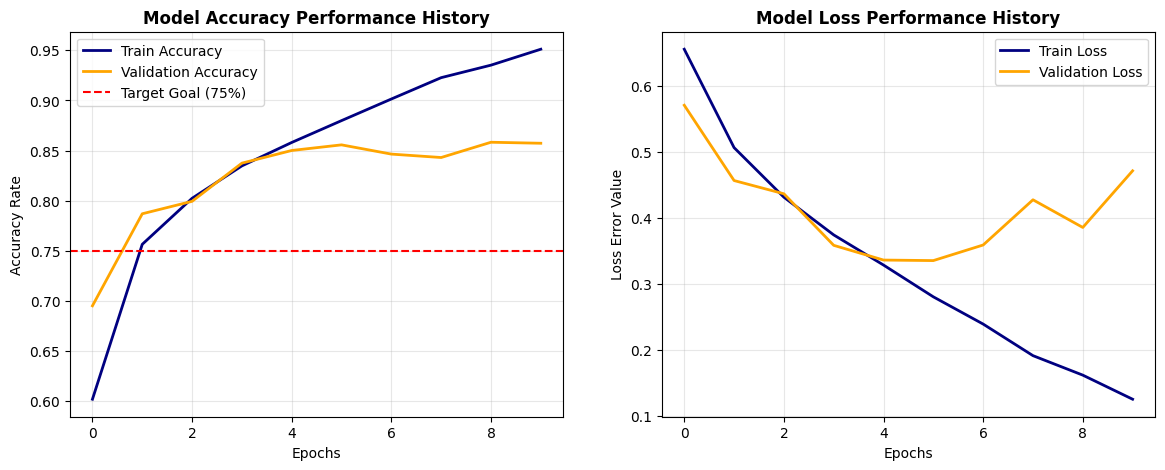

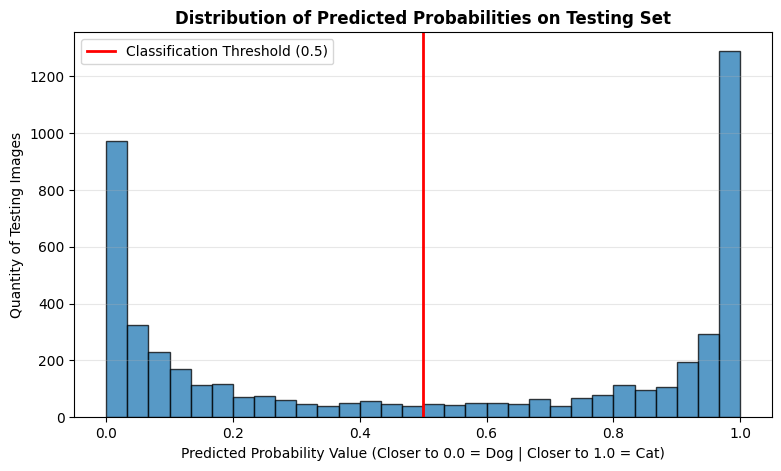

In [13]:
#run evaluations against testing  and creating structural data visuals.

test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print("\n" + "="*40)
print(f"  FINAL TESTING ACCURACY: {test_accuracy * 100:.2f}%")
print(f"  FINAL TESTING LOSS:     {test_loss:.4f}")
print("="*40 + "\n")

# 1. plot accuracy & loss performance metrics
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history.history['accuracy'], label='Train Accuracy', color='navy', lw=2)
ax1.plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange', lw=2)
ax1.axhline(0.75, color='red', linestyle='--', label='Target Goal (75%)')
ax1.set_title('Model Accuracy Performance History', fontsize=12, weight='bold')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Accuracy Rate')
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(history.history['loss'], label='Train Loss', color='navy', lw=2)
ax2.plot(history.history['val_loss'], label='Validation Loss', color='orange', lw=2)
ax2.set_title('Model Loss Performance History', fontsize=12, weight='bold')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Loss Error Value')
ax2.legend()
ax2.grid(alpha=0.3)
plt.show()

# 2. probability distribution plot
y_probabilities = model.predict(X_test, verbose=0)

plt.figure(figsize=(9, 5))
plt.hist(y_probabilities, bins=30, edgecolor='black', color='#1f77b4', alpha=0.75)
plt.axvline(0.5, color='red', linestyle='-', linewidth=2, label='Classification Threshold (0.5)')
# lable mapping
plt.title('Distribution of Predicted Probabilities on Testing Set', fontsize=12, weight='bold')
plt.xlabel('Predicted Probability Value (Closer to 0.0 = Dog | Closer to 1.0 = Cat)')
plt.ylabel('Quantity of Testing Images')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

Accessing resource image: https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/dog.jpg


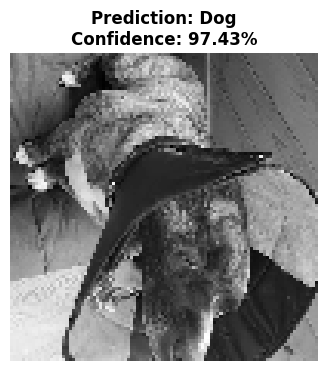

In [14]:
# testing function to evaluate the network against the external S3 sample file.

def predict_external_s3_image(img_url, trained_model):
    print(f"Accessing resource image: {img_url}")
    response = requests.get(img_url)

    # 1. load image as a 100x100 grayscale asset
    img = image.load_img(BytesIO(response.content), target_size=(100, 100), color_mode="grayscale")

    # 2. map pixels to a numpy array matrix and scale from 0 to 1
    img_array = image.img_to_array(img) / 255.0

    # 3. rotate the image 90 degrees clockwise (axes=(1, 0)) so the dog is right-side up!
    img_array_fixed = np.rot90(img_array, k=-1, axes=(0, 1))

    # 4. reshape / expand dimensions from 3D array (100,100,1) to 4D batch tensor (1,100,100,1)d
    img_4d = np.expand_dims(img_array_fixed, axis=0)

    # 5. run inference
    raw_prob = trained_model.predict(img_4d, verbose=0)[0][0]

    # 6. corrected target mapping: 0.0 = Dog, 1.0 = Cat
    if raw_prob >= 0.5:
        predicted_class = "Cat"
        confidence_metric = raw_prob
    else:
        predicted_class = "Dog"
        confidence_metric = 1 - raw_prob

    # render final corrected high-confidence output visualization report
    plt.figure(figsize=(4, 4))
    plt.imshow(img_array_fixed.squeeze(), cmap='gray')
    plt.title(f"Prediction: {predicted_class}\nConfidence: {confidence_metric*100:.2f}%", fontsize=12, weight='bold')
    plt.axis('off')
    plt.show()

    return predicted_class, raw_prob

# define target address path
target_dog_url = "https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/dog.jpg"

# run validation with the correct orientation
final_label, final_raw_score = predict_external_s3_image(target_dog_url, model)

## **BONUS** (optional)



* Upload an image of your (or your friend's or family's) dog or cat and use your model to predict whether the image is a dog or cat.
* Hint: you'll probably need to convert the image from color to grayscale.  OpenCV, pillow, and other libraries are your friend.